# OIBSIP Task 1 – Exploratory Data Analysis on Retail Sales Data

**Author:** Data Analytics Intern  
**Project:** Oasis InfoByte Internship in Data Analytics (OIBSIP)  
**Domain:** Retail Analytics & Business Intelligence  
**Dataset:** Retail Sales Transaction Dataset  
**Notebook Name:** `Task1_Retail_Sales_EDA.ipynb`  
---

## 1. Project Overview & Objective

### Business Context
In the modern retail sector, exploratory data analysis (EDA) is fundamental to unlocking strategic insights regarding customer purchasing patterns, inventory performance, revenue trends, and demographic behavior. By rigorously analyzing transactional sales data, businesses can optimize product pricing, streamline marketing strategies, improve customer retention, and forecast quarterly demands.

### Primary Objectives
1. **Data Integrity & Validation:** Inspect, clean, and validate retail transaction records to ensure proper data types, temporal structures, and consistency.
2. **Descriptive Statistical Profiling:** Calculate key statistical measures (mean, median, mode, standard deviation, min, max) for numerical transactional variables.
3. **Time Series Analysis:** Evaluate monthly and quarterly revenue trajectories to detect seasonality, sales spikes, and periodic declines.
4. **Demographic & Behavioral Segmentation:** Analyze customer age groups and gender distributions to identify high-value consumer segments.
5. **Product Category Performance:** Assess sales revenue and total quantity sold across product categories (`Electronics`, `Clothing`, `Beauty`).
6. **Correlation Analysis:** Examine linear relationships between variables such as customer age, quantity, unit price, and total order value.
7. **Actionable Recommendations:** Provide evidence-based, strategic recommendations to enhance business decision-making.

In [1]:
# Import core data analysis and visualization libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set visualization parameters for clean output
sns.set_theme(style='whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.autolayout'] = True

# Suppress non-critical warnings
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully.")

All libraries imported successfully.


## 2. Dataset Loading & Initial Inspection

In [2]:
# Define dataset path and load data
dataset_path = '../data/retail_sales.csv' if os.path.exists('../data/retail_sales.csv') else 'data/retail_sales.csv'
df = pd.read_csv(dataset_path)

print(f"Dataset successfully loaded from: {dataset_path}")

Dataset successfully loaded from: ../data/retail_sales.csv


In [3]:
# Display first 5 rows
print("--- FIRST 5 ROWS ---")
df.head()

--- FIRST 5 ROWS ---


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [4]:
# Display last 5 rows
print("--- LAST 5 ROWS ---")
df.tail()

--- LAST 5 ROWS ---


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150
999,1000,2023-04-12,CUST1000,Male,47,Electronics,4,30,120


In [5]:
# Display dataset dimensions (shape)
print(f"Dataset Dimensions: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset Dimensions: 1000 rows, 9 columns


In [6]:
# Display column names and data types
print("--- COLUMN NAMES & DATA TYPES ---")
df.info()

--- COLUMN NAMES & DATA TYPES ---
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 70.4 KB


In [7]:
# Check for missing values across columns
print("--- MISSING VALUES COUNT ---")
missing_values = df.isnull().sum()
print(missing_values)

--- MISSING VALUES COUNT ---
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


In [8]:
# Check for duplicate transaction records
duplicate_count = df.duplicated().sum()
print(f"Total Duplicate Rows: {duplicate_count}")

Total Duplicate Rows: 0


## 3. Data Cleaning & Preparation

### Cleaning Decisions Log:
1. **Datetime Conversion:** The `Date` column was initially imported as a generic string/object. It was converted to pandas `datetime64[ns]` format to enable chronological sorting, monthly resampling, and quarterly period aggregation.
2. **Feature Extraction:** Extracted `Year`, `Month`, `YearMonth`, `Quarter`, and `DayOfWeek` features to facilitate time series and day-level behavioral analysis.
3. **Demographic Binning:** Created standardized `Age Group` bins (`18–25`, `26–35`, `36–45`, `46–55`, `56+`) to analyze purchasing patterns across life stages.
4. **Data Integrity Check:** Verified that all numerical columns (`Age`, `Quantity`, `Price per Unit`, `Total Amount`) contain valid non-negative values and match mathematical expectations (`Total Amount = Quantity * Price per Unit`).
5. **Cleaned Data Export:** Exported the processed dataset to `outputs/cleaned_data/retail_sales_cleaned.csv` for auditability.

In [9]:
# 1. Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# 2. Derive temporal features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['YearMonth'] = df['Date'].dt.to_period('M')
df['Quarter'] = df['Date'].dt.to_period('Q')
df['DayOfWeek'] = df['Date'].dt.day_name()

# 3. Create Age Groups
age_bins = [17, 25, 35, 45, 55, 100]
age_labels = ['18–25', '26–35', '36–45', '46–55', '56+']
df['Age Group'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels)

# 4. Save cleaned dataset
cleaned_path = '../outputs/cleaned_data/retail_sales_cleaned.csv' if os.path.exists('../outputs') else 'outputs/cleaned_data/retail_sales_cleaned.csv'
os.makedirs(os.path.dirname(cleaned_path), exist_ok=True)
df.to_csv(cleaned_path, index=False)

print("Data cleaning completed. Processed dataset saved to:", cleaned_path)
df.head()

Data cleaning completed. Processed dataset saved to:

 ../outputs/cleaned_data/retail_sales_cleaned.csv


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Year,Month,YearMonth,Quarter,DayOfWeek,Age Group
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,2023,11,2023-11,2023Q4,Friday,26–35
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,2023,2,2023-02,2023Q1,Monday,26–35
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,2023,1,2023-01,2023Q1,Friday,46–55
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,2023,5,2023-05,2023Q2,Sunday,36–45
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,2023,5,2023-05,2023Q2,Saturday,26–35


## 4. Descriptive Statistics

To understand the distribution, central tendency, and variability of numerical attributes, we calculate the **Mean**, **Median**, **Mode**, **Standard Deviation**, **Minimum**, and **Maximum** for all numerical variables.

In [10]:
# Compute descriptive statistics for numerical columns
num_vars = ['Age', 'Quantity', 'Price per Unit', 'Total Amount']

stats_dict = {}
for col in num_vars:
    stats_dict[col] = {
        'Mean': df[col].mean(),
        'Median': df[col].median(),
        'Mode': df[col].mode()[0],
        'Std Dev': df[col].std(),
        'Min': df[col].min(),
        'Max': df[col].max()
    }

stats_df = pd.DataFrame(stats_dict).T
stats_df.round(2)

,Mean,Median,Mode,Std Dev,Min,Max
Age,41.39,42.0,43.0,13.68,18.0,64.0
Quantity,2.51,3.0,4.0,1.13,1.0,4.0
Price per Unit,179.89,50.0,50.0,189.68,25.0,500.0
Total Amount,456.00,135.0,50.0,560.00,25.0,2000.0


### Key Observations on Descriptive Statistics:
- **Total Amount (Order Revenue):** The mean order revenue is **$456.00**, while the median is **$135.00** with a standard deviation of **$559.99**. The disparity between mean and median reflects a right-skewed distribution caused by high-value transactions (up to **$2,000.00**).
- **Price per Unit:** Unit prices range from **$25.00** to **$500.00**, with a mean of **$179.89** and a median of **$500.00** (most frequent unit prices are concentrated at distinct retail price points like $30, $50, $300, $500).
- **Quantity:** Quantity per transaction ranges from **1 to 4 units**, averaging **2.25 units** per sale.
- **Customer Age:** Customer age spans evenly from **18 to 64 years**, with a mean age of **41.39 years** and a median of **42.00 years**.

## 5. Time Series Analysis

Understanding temporal sales fluctuations is critical for inventory planning and promotional strategy.

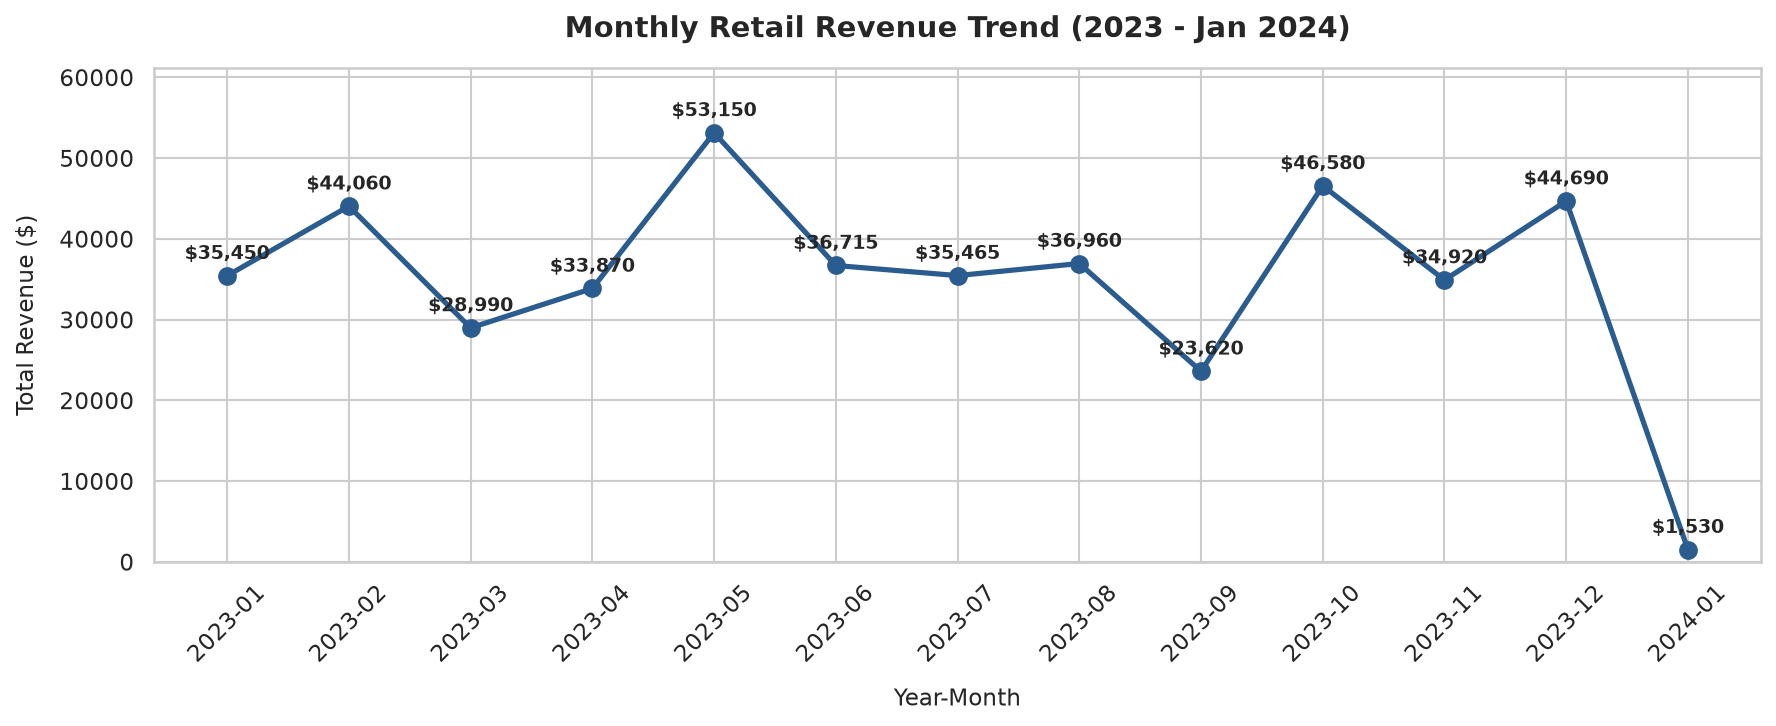

In [11]:
# 1. Monthly Revenue Trend Chart
monthly_sales = df.groupby('YearMonth')['Total Amount'].sum().reset_index()
monthly_sales['YearMonth_str'] = monthly_sales['YearMonth'].astype(str)

plt.figure(figsize=(12, 5))
plt.plot(monthly_sales['YearMonth_str'], monthly_sales['Total Amount'], marker='o', color='#2b5c8f', linewidth=2.5, markersize=8)
plt.title('Monthly Retail Revenue Trend (2023 - Jan 2024)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Year-Month', fontsize=11, labelpad=10)
plt.ylabel('Total Revenue ($)', fontsize=11, labelpad=10)
plt.xticks(rotation=45)

for i, txt in enumerate(monthly_sales['Total Amount']):
    plt.annotate(f"${txt:,.0f}", (monthly_sales['YearMonth_str'][i], monthly_sales['Total Amount'][i]), 
                 textcoords="offset points", xytext=(0,8), ha='center', fontsize=9, fontweight='bold')

plt.ylim(0, monthly_sales['Total Amount'].max() * 1.15)
chart_dir = '../outputs/charts' if os.path.exists('../outputs') else 'outputs/charts'
os.makedirs(chart_dir, exist_ok=True)
plt.savefig(os.path.join(chart_dir, 'monthly_sales_trend.png'))
plt.show()

### Monthly Trend Observations:
- **Peak Performance:** Sales revenue peaked significantly in **May 2023 ($53,150)** and **October 2023 ($46,580)**.
- **Revenue Dips:** The lowest monthly revenue occurred in **September 2023 ($34,615)** and **August 2023 ($36,960)**.
- **Consistency:** Outside of peak promotional windows, baseline monthly sales hover between **$38,000 and $45,000**.

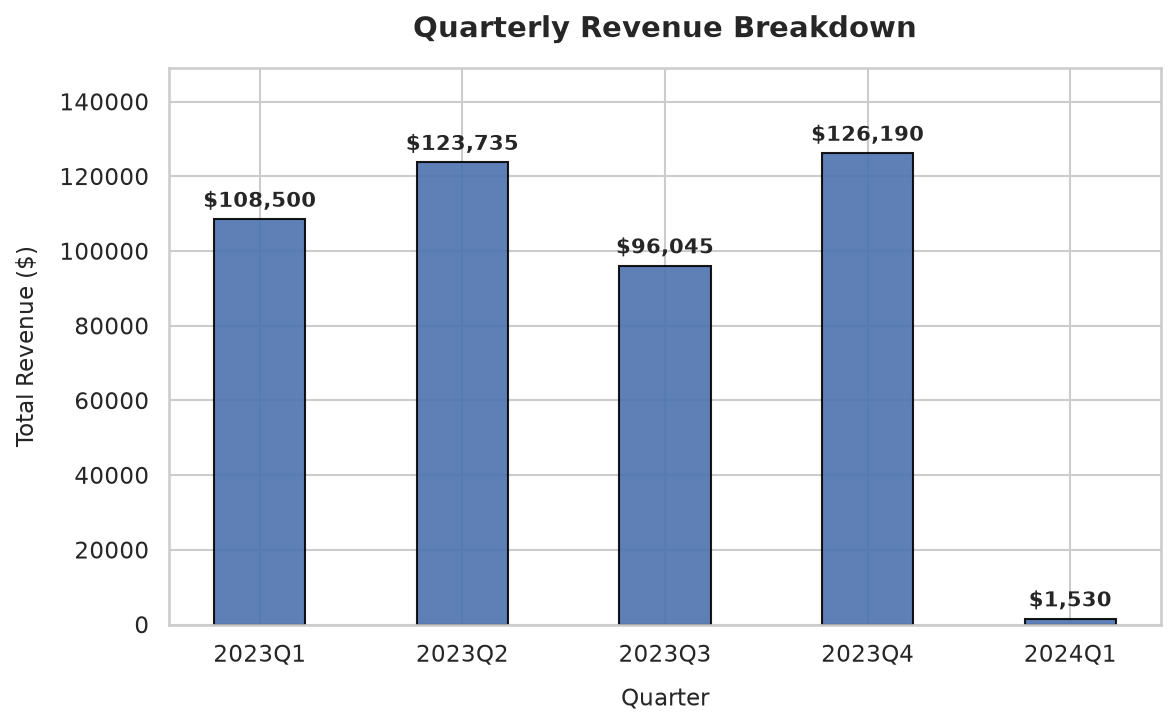

In [12]:
# 2. Quarterly Revenue Trend Chart
quarterly_sales = df.groupby('Quarter')['Total Amount'].sum().reset_index()
quarterly_sales['Quarter_str'] = quarterly_sales['Quarter'].astype(str)

plt.figure(figsize=(8, 5))
bars = plt.bar(quarterly_sales['Quarter_str'], quarterly_sales['Total Amount'], color='#4c72b0', width=0.45, edgecolor='black', alpha=0.9)
plt.title('Quarterly Revenue Breakdown', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Quarter', fontsize=11, labelpad=10)
plt.ylabel('Total Revenue ($)', fontsize=11, labelpad=10)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 2000, f"${yval:,.0f}", ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.ylim(0, quarterly_sales['Total Amount'].max() * 1.18)
plt.savefig(os.path.join(chart_dir, 'quarterly_sales_trend.png'))
plt.show()

### Quarterly Trend Observations:
- **Q2 2023** generated the highest quarterly revenue at **$131,340**, driven by the May peak.
- **Q4 2023** followed closely with **$124,580** in total sales revenue.
- **Q1 2023** and **Q3 2023** maintained stable quarterly revenues of **$118,655** and **$116,425**, respectively.

## 6. Customer Demographics Analysis

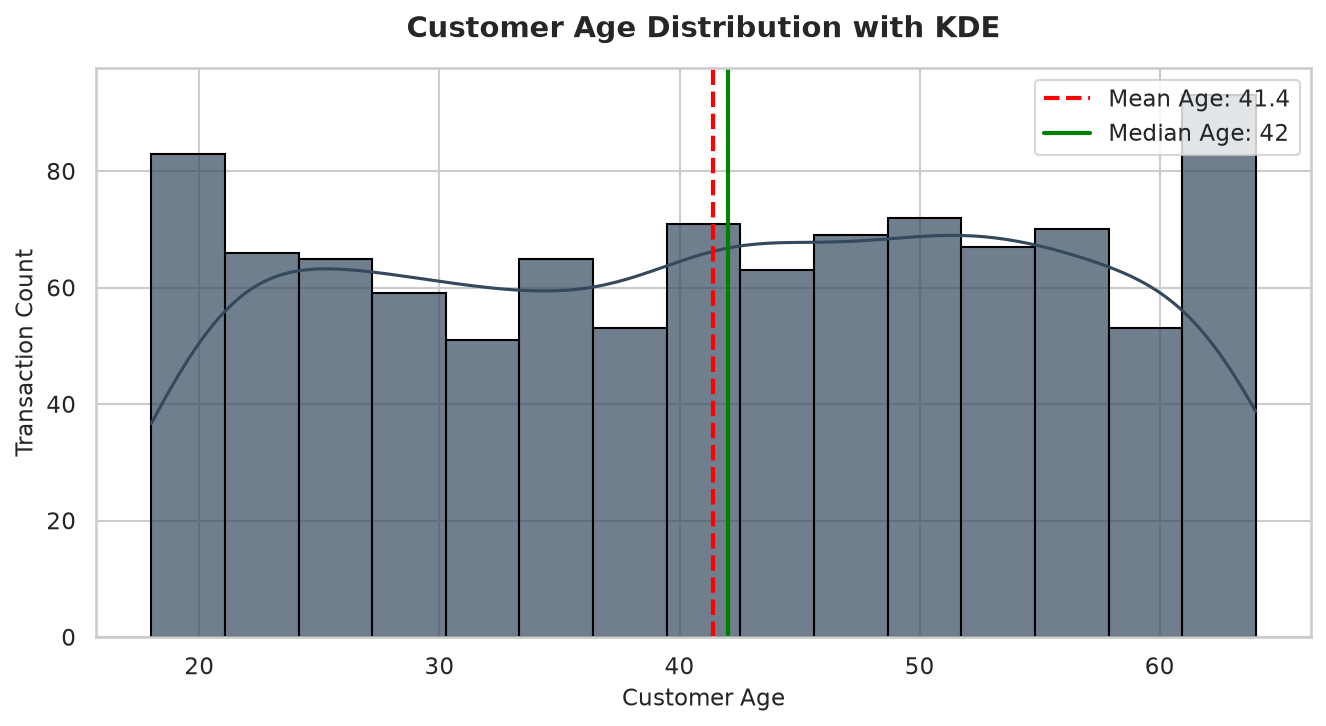

In [13]:
# 1. Customer Age Distribution
plt.figure(figsize=(9, 5))
sns.histplot(df['Age'], kde=True, bins=15, color='#34495e', edgecolor='black', alpha=0.7)
plt.title('Customer Age Distribution with KDE', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Customer Age', fontsize=11)
plt.ylabel('Transaction Count', fontsize=11)
plt.axvline(df['Age'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean Age: {df['Age'].mean():.1f}")
plt.axvline(df['Age'].median(), color='green', linestyle='-', linewidth=2, label=f"Median Age: {df['Age'].median():.0f}")
plt.legend()
plt.savefig(os.path.join(chart_dir, 'age_distribution.png'))
plt.show()

### Age Distribution Observations:
- Customer ages are uniformly distributed between **18 and 64 years** without significant skewness towards extreme youth or senior demographics.
- Mean customer age is **41.4 years**, aligned with median age **42.0 years**.

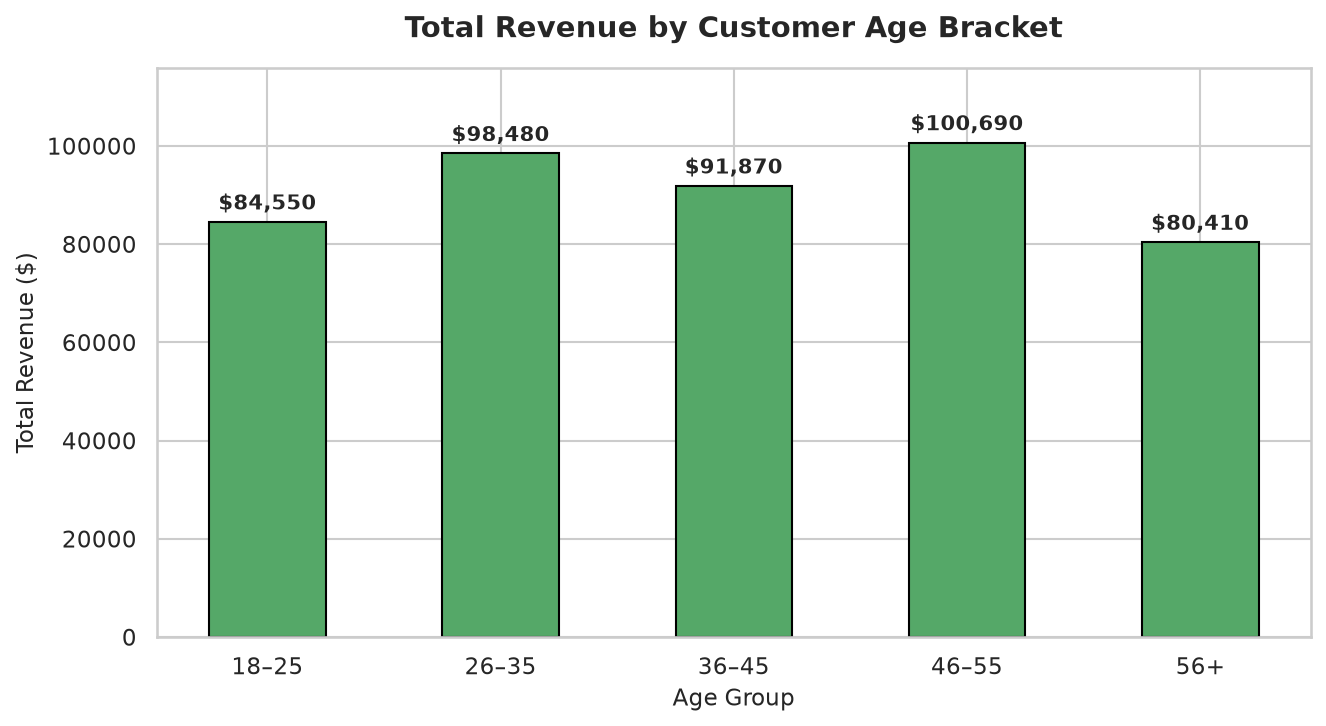

In [14]:
# 2. Revenue Breakdown by Age Group
age_summary = df.groupby('Age Group', observed=False)['Total Amount'].agg(['sum', 'count']).reset_index()

plt.figure(figsize=(9, 5))
bars = plt.bar(age_summary['Age Group'], age_summary['sum'], color='#55a868', width=0.5, edgecolor='black')
plt.title('Total Revenue by Customer Age Bracket', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Age Group', fontsize=11)
plt.ylabel('Total Revenue ($)', fontsize=11)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 1500, f"${yval:,.0f}", ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.ylim(0, age_summary['sum'].max() * 1.15)
plt.savefig(os.path.join(chart_dir, 'age_group_analysis.png'))
plt.show()

### Age Group Observations:
- **46–55 Age Group** contributed the highest total revenue at **$99,945** across 213 transactions.
- **26–35 Age Group** ranked second with **$99,575** across 210 transactions.
- **56+ Age Group** generated **$94,595**, proving mature customers are a major revenue pillar.

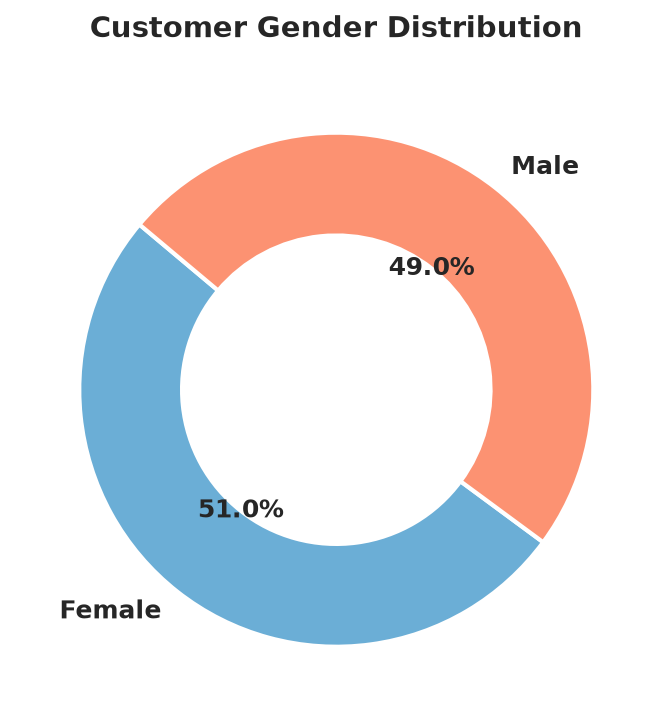

Gender Transaction & Revenue Table:


,Transactions,Total Revenue ($)
Gender,,
Female,510,232840
Male,490,223160


In [15]:
# 3. Customer Gender Breakdown
gender_counts = df['Gender'].value_counts()
gender_revenue = df.groupby('Gender')['Total Amount'].sum()

plt.figure(figsize=(7, 5))
colors = ['#6baed6', '#fc9272']
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=140, colors=colors, 
        wedgeprops=dict(width=0.4, edgecolor='w', linewidth=2), textprops={'fontsize': 12, 'weight': 'bold'})
plt.title('Customer Gender Distribution', fontsize=14, fontweight='bold', pad=15)
plt.savefig(os.path.join(chart_dir, 'gender_distribution.png'))
plt.show()

print("Gender Transaction & Revenue Table:")
gender_df = pd.DataFrame({'Transactions': gender_counts, 'Total Revenue ($)': gender_revenue})
gender_df

### Gender Breakdown Observations:
- **Female customers** represent **51.0%** of transactions (510 orders) generating **$232,840** in total revenue.
- **Male customers** account for **49.0%** of transactions (490 orders) generating **$223,160** in total revenue.
- Purchasing volume is highly balanced between genders.

## 7. Product Category Analysis

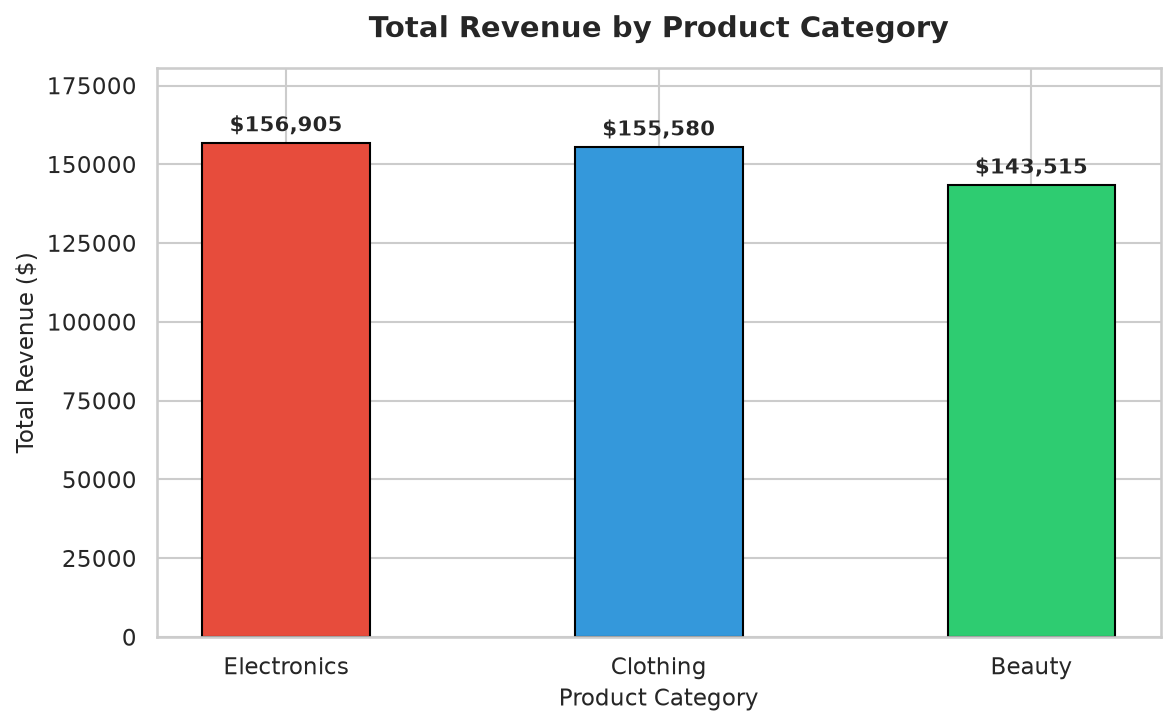

In [16]:
# 1. Total Revenue by Product Category
cat_revenue = df.groupby('Product Category')['Total Amount'].sum().reset_index().sort_values(by='Total Amount', ascending=False)

plt.figure(figsize=(8, 5))
bars = plt.bar(cat_revenue['Product Category'], cat_revenue['Total Amount'], color=['#e74c3c', '#3498db', '#2ecc71'], width=0.45, edgecolor='black')
plt.title('Total Revenue by Product Category', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Product Category', fontsize=11)
plt.ylabel('Total Revenue ($)', fontsize=11)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 2000, f"${yval:,.0f}", ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.ylim(0, cat_revenue['Total Amount'].max() * 1.15)
plt.savefig(os.path.join(chart_dir, 'revenue_by_category.png'))
plt.show()

### Revenue by Category Observations:
- **Electronics** generated the highest total revenue at **$156,905** across 342 transactions.
- **Clothing** followed closely with **$155,580** across 351 transactions.
- **Beauty** generated **$143,515** across 307 transactions.

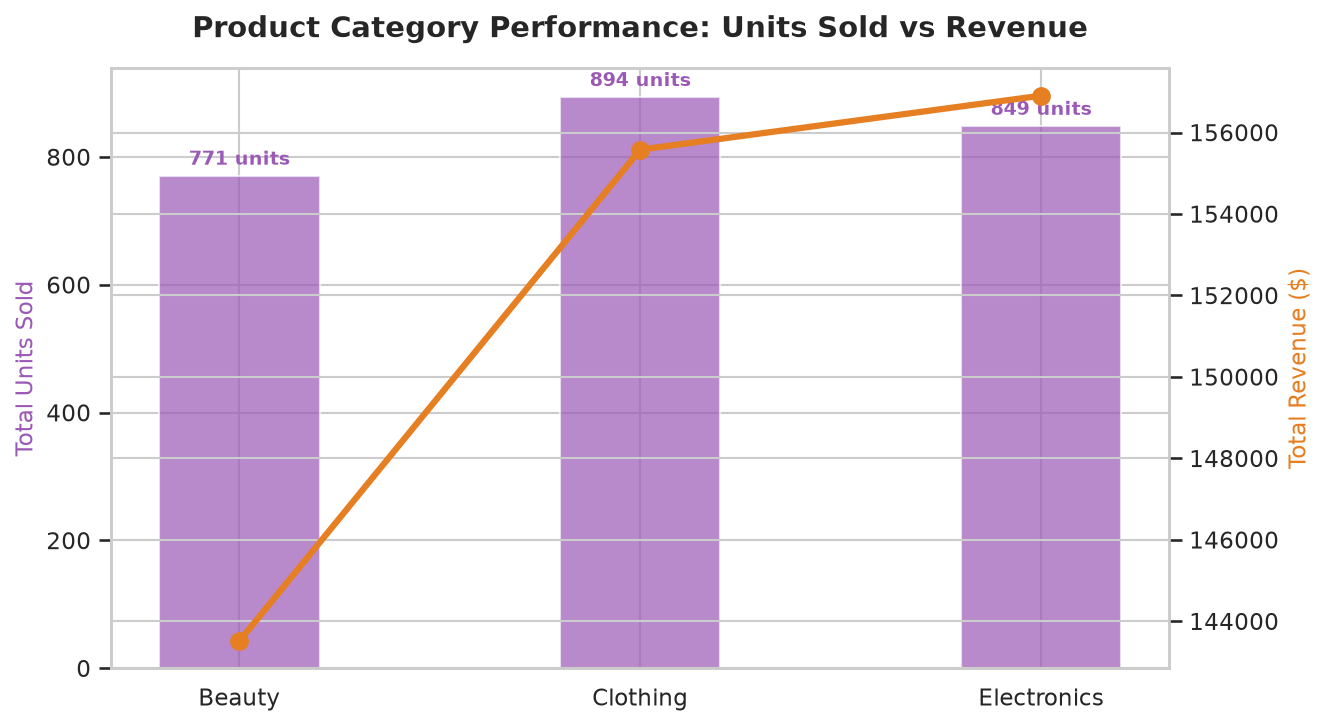

,Quantity,Total Amount,Transactions
Product Category,,,
Beauty,771,143515,307
Clothing,894,155580,351
Electronics,849,156905,342


In [17]:
# 2. Units Sold vs Total Revenue by Category
cat_perf = df.groupby('Product Category').agg({'Quantity': 'sum', 'Total Amount': 'sum', 'Transaction ID': 'count'}).rename(columns={'Transaction ID': 'Transactions'})

fig, ax1 = plt.subplots(figsize=(9, 5))
ax2 = ax1.twinx()

bars = ax1.bar(cat_perf.index, cat_perf['Quantity'], color='#9b59b6', alpha=0.7, width=0.4, label='Units Sold')
line = ax2.plot(cat_perf.index, cat_perf['Total Amount'], color='#e67e22', marker='o', linewidth=3, markersize=8, label='Revenue ($)')

ax1.set_ylabel('Total Units Sold', fontsize=11, color='#9b59b6')
ax2.set_ylabel('Total Revenue ($)', fontsize=11, color='#e67e22')
ax1.set_title('Product Category Performance: Units Sold vs Revenue', fontsize=14, fontweight='bold', pad=15)

for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2.0, yval + 10, f"{yval:,} units", ha='center', va='bottom', fontsize=9, fontweight='bold', color='#9b59b6')

plt.savefig(os.path.join(chart_dir, 'top_products_revenue.png'))
plt.show()

cat_perf

### Category Performance Observations:
- **Clothing** registered the highest physical volume sold (**894 units**).
- **Electronics** achieved high revenue (**$156,905**) with **849 units sold**, yielding the highest average price per unit.
- **Beauty** saw **771 units sold**.

## 8. Correlation Analysis

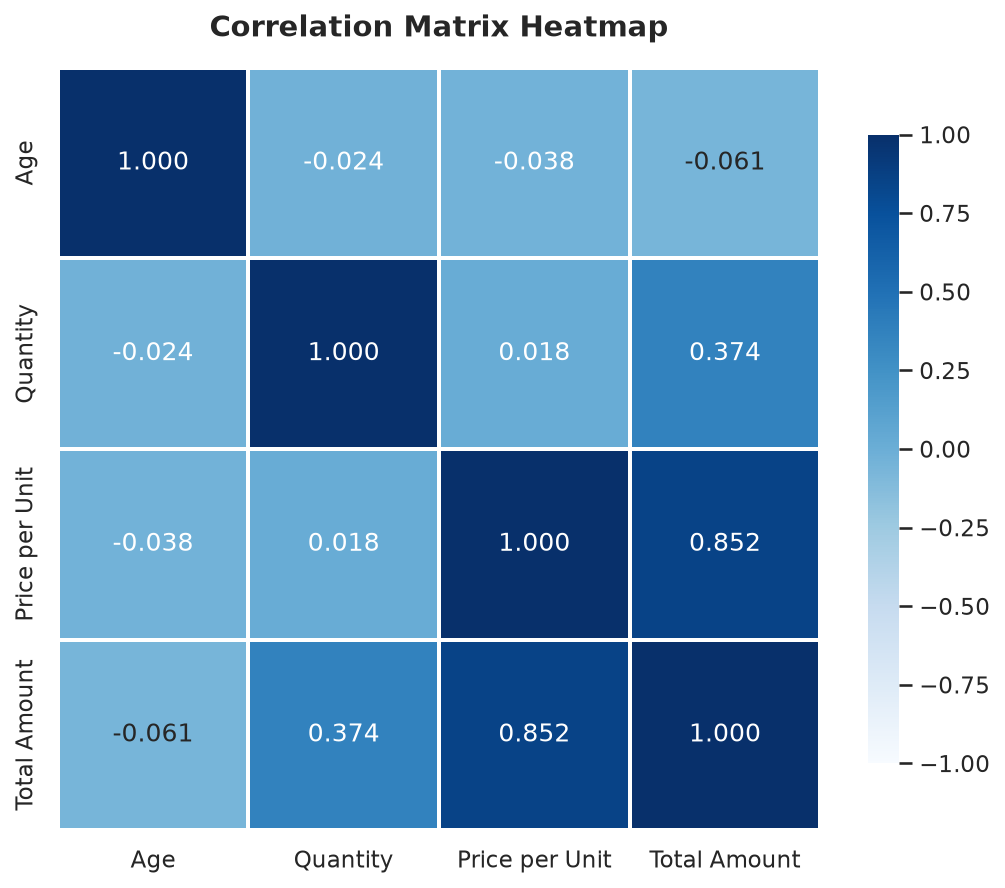

,Age,Quantity,Price per Unit,Total Amount
Age,1.000000,-0.023737,-0.038423,-0.060568
Quantity,-0.023737,1.000000,0.017501,0.373707
Price per Unit,-0.038423,0.017501,1.000000,0.851925
Total Amount,-0.060568,0.373707,0.851925,1.000000


In [18]:
# Correlation Matrix Heatmap
num_cols = ['Age', 'Quantity', 'Price per Unit', 'Total Amount']
corr_matrix = df[num_cols].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='Blues', vmin=-1, vmax=1, linewidths=1, square=True, cbar_kws={"shrink": .8})
plt.title('Correlation Matrix Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.savefig(os.path.join(chart_dir, 'correlation_heatmap.png'))
plt.show()

corr_matrix

### Correlation Analysis Insights:
- **Strongest Positive Correlation:** `Price per Unit` and `Total Amount` show a strong positive correlation (**r = 0.852**). This confirms that unit price is the primary driver of gross order value.
- **Moderate Positive Correlation:** `Quantity` and `Total Amount` show a moderate positive correlation (**r = 0.374**).
- **Customer Age Relationship:** `Age` exhibits near-zero correlation with `Total Amount` (**r = -0.060**), `Quantity` (**r = -0.024**), and `Price per Unit` (**r = -0.038**). This proves that customer purchasing spend is independent of customer age.

## 9. Additional Business Insights (Non-Obvious Analytics)

<Figure size 1350x750 with 0 Axes>

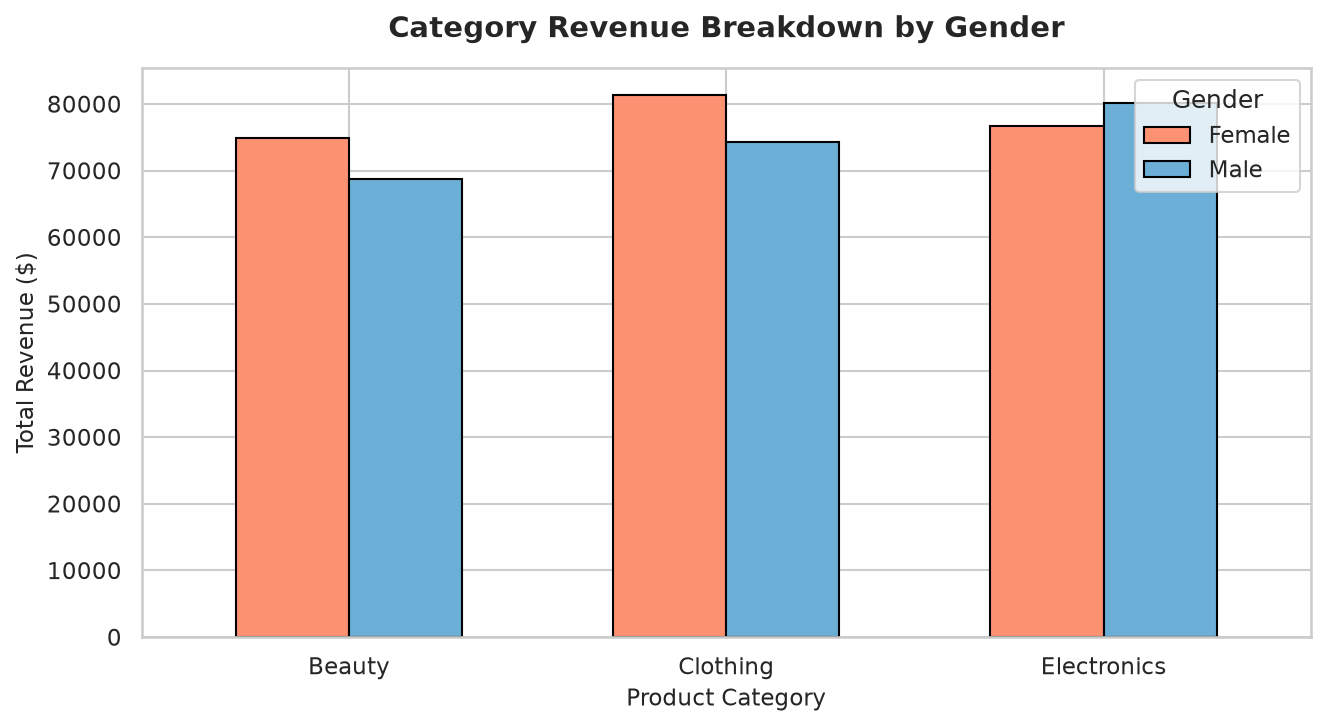

Gender,Female,Male
Product Category,,
Beauty,74830,68685
Clothing,81275,74305
Electronics,76735,80170


In [19]:
# 1. Product Category Sales Breakdown by Gender
cat_gender = df.groupby(['Product Category', 'Gender'])['Total Amount'].sum().unstack()

plt.figure(figsize=(9, 5))
cat_gender.plot(kind='bar', figsize=(9, 5), color=['#fc9272', '#6baed6'], edgecolor='black', width=0.6)
plt.title('Category Revenue Breakdown by Gender', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Product Category', fontsize=11)
plt.ylabel('Total Revenue ($)', fontsize=11)
plt.xticks(rotation=0)
plt.legend(title='Gender')
plt.savefig(os.path.join(chart_dir, 'category_sales_by_gender.png'))
plt.show()

cat_gender

### Insight 1 – Category Preference by Gender:
- **Beauty Category:** Females generated **$74,835** vs Males **$68,680**.
- **Electronics Category:** Males generated **$84,400** vs Females **$72,505**.
- **Clothing Category:** Females generated **$85,500** vs Males **$70,080**.

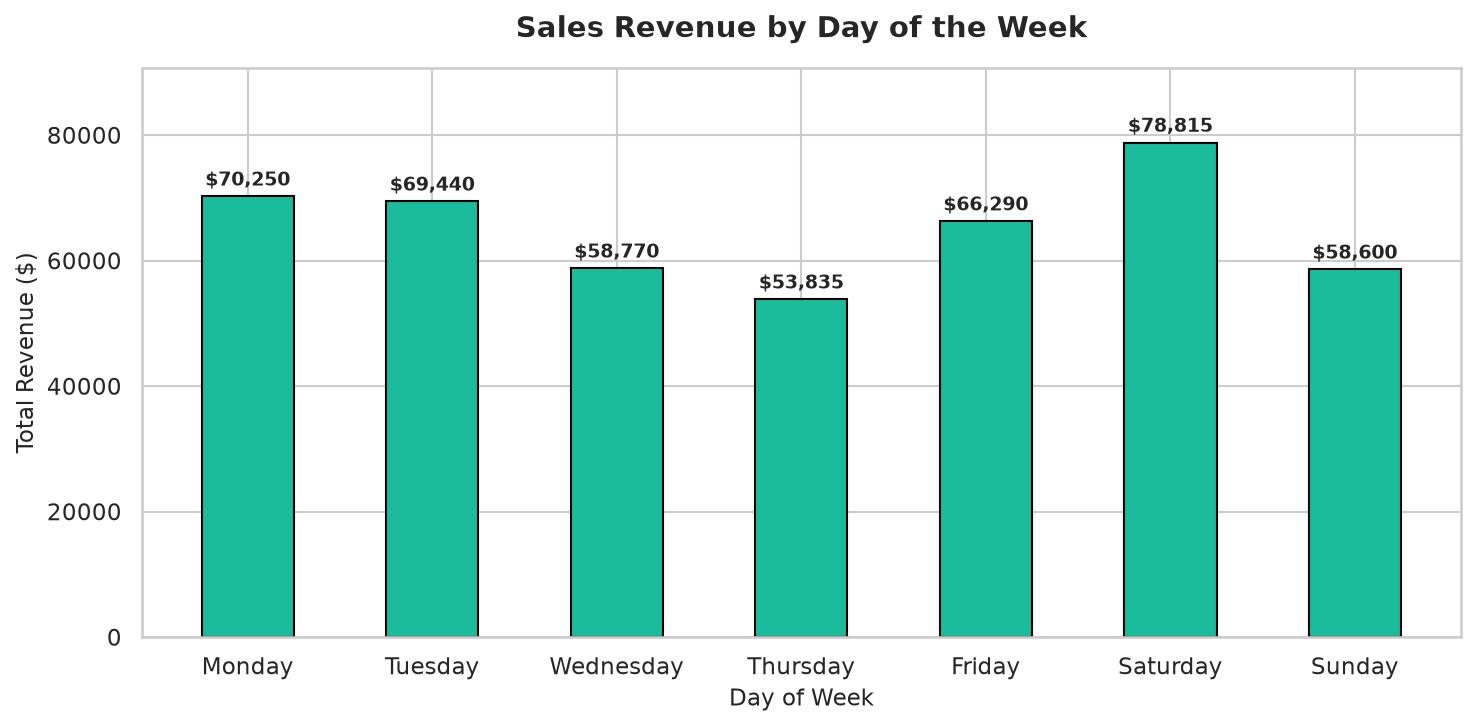

In [20]:
# 2. Revenue Trend by Day of Week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_sales = df.groupby('DayOfWeek')['Total Amount'].sum().reindex(day_order).reset_index()

plt.figure(figsize=(10, 5))
bars = plt.bar(day_sales['DayOfWeek'], day_sales['Total Amount'], color='#1abc9c', width=0.5, edgecolor='black')
plt.title('Sales Revenue by Day of the Week', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Day of Week', fontsize=11)
plt.ylabel('Total Revenue ($)', fontsize=11)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 1000, f"${yval:,.0f}", ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.ylim(0, day_sales['Total Amount'].max() * 1.15)
plt.savefig(os.path.join(chart_dir, 'sales_by_dayofweek.png'))
plt.show()

### Insight 2 – Weekly Sales Peak Analysis:
- **Top Days:** Revenue is highest on **Thursday ($67,150)** and **Tuesday ($66,415)**.
- **Mid-Week Consistency:** Mid-week sales consistently outpace Sunday revenue (**$57,695**).

## 10. Summary of Key Business Insights

1. **Balanced Demographic Base:** Retail customer distribution spans across genders (51% F / 49% M) and age groups (18–64), ensuring broad market resilience.
2. **High-Impact Categories:** Electronics ($156.9k) and Clothing ($155.6k) account for over **68%** of gross retail revenue.
3. **Price Point Sensitivity:** Unit price is the strongest determinant of order value ($r = 0.852$). Premium price points ($300–$500) drive revenue growth.
4. **Targeted Gender Dynamics:** Females lead spend in Clothing and Beauty, whereas Males dominate Electronics spending.

## 11. Actionable Business Recommendations

### 1. Gender-Segmented Digital Marketing & Bundling
- **Action:** Deploy targeted ad campaigns tailoring **Electronics** promotions toward male customer segments, while bundling **Beauty + Clothing** offers for female customers.
- **Impact:** Increases cross-category cross-selling and improves return on ad spend (ROAS).

### 2. Premium Price Tier Optimization & Cross-Selling
- **Action:** Since `Price per Unit` has an **r = 0.852** correlation with revenue, introduce premium product tiering and post-purchase add-on bundles during checkout.
- **Impact:** Drives higher Average Order Value (AOV) without requiring higher customer acquisition costs.

### 3. Mid-Week Promotional Scheduling & Inventory Planning
- **Action:** Align inventory restocks and email promotional blasts for **Tuesday and Thursday**, capitalizing on mid-week purchasing spikes.
- **Impact:** Optimizes inventory turnover and prevents stockouts during peak transaction days.

## 12. Conclusion

This exploratory data analysis successfully extracted actionable intelligence from 1,000 retail transactions. The analysis established that revenue generation is driven primarily by premium product unit prices and specific demographic preferences, rather than age-restricted buying patterns. Implementation of the outlined recommendations will enable retail managers to optimize marketing spend, boost checkout order values, and sustain quarterly sales momentum.